In [ ]:
import sympy
from sympy import Ellipse, Point, S, Eq, latex, plot_implicit, solve
from sympy import symbols, simplify, Rational, Matrix, Line
from sympy import cos as Cos
from sympy import sin as Sin
from IPython.display import Latex

# Практическое занятие 15
# Компьютерный практикум по алгебре на Python
### Задание 1.
Построить эллипс с центром в точке А(1, 2), полуосями 3 и 2. Вычислить и вывести на экран эксцентриситет, площадь и длину дуги полученного эллипса, центр, полуоси, periapsis, apoapsis, межфокусное расстояние и фокусы.

Указание: составить словарь с ключами - названиями ('center', 'hradius', 'vradius' и т.п.) и значениями - атрибутами эллипса (.center, .hradius, ...), затем в цикле вывести все значения атрибутов из словаря вместе с названиями, например, "hradius=3".

In [ ]:
Ellipse1 = Ellipse(Point(1, 2), hradius=3,  vradius=2)
values = {'center': Ellipse1.center,
         'hradius': Ellipse1.hradius,
         'vradius': Ellipse1.vradius,
         'area': Ellipse1.area,
         'circumference': Ellipse1.circumference,
         'eccentricity': Ellipse1.eccentricity,
         'periapsis': Ellipse1.periapsis,
         'apoapsis': Ellipse1.apoapsis,
         'focus\_distance': Ellipse1.focus_distance,
         'foci': Ellipse1.foci}
display(*[Latex(f'{key} = {latex(values[key])}') for key in values])

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

### Задание 2.
Вывести на экран **уравнение** эллипса из задания 1, повернутого на 30 градусов против часовой стрелки относительно его центра,  переменные $u$ и $v$.

Изобразить на общем графике эллипс и повернутый эллипс.

**Указание:** по углу определить значение _slope аргумента метода equation (это тангенс угла наклона), использовать plot_implicit.

In [ ]:
expr1 = Ellipse1.equation(x='u', y='v')
expr2 = Ellipse1.equation(x='u', y='v', _slope=S(1) / sympy.sqrt(3))
display(expr2)

(u + sqrt(3)*(v - 2)/3 - 1)**2/12 + 3*(v - sqrt(3)*(u - 1)/3 - 2)**2/16 - 1

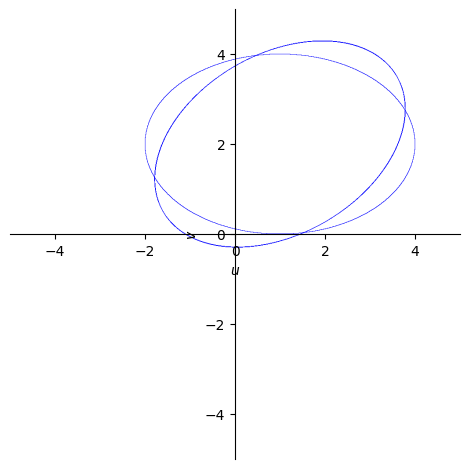

In [ ]:
plt = plot_implicit(expr1,
                    aspect_ratio=(1, 1),
                    *[(variable, -5, 5) for variable in expr1.free_symbols], show=False)
plt.append(plot_implicit(expr2,
                         aspect_ratio=(1, 1),
                         *[(variable, -5, 5) for variable in expr2.free_symbols], show=False)[0])
plt.show()

### Задание 3.
Найти вершины эллипса из Задания 1.

**Указание:** вершины эллипса искать как решение системы уравнений, составленной из уравнения эллипса и уравнения прямой, проходящей через форкусы (воспользоваться Line и методом equation()); вторую пару вершин получить как решение системы из уравнения эллипса и прямой, проходящей через центр эллипса перпендикулярно прямой, проходящей через фокусы.

In [ ]:
from sympy.abc import x, y

In [ ]:
display(Line(*Ellipse1.foci).equation(), Ellipse1.equation())

y - 2

(x/3 - 1/3)**2 + (y/2 - 1)**2 - 1

In [ ]:
peaks = solve([Line(*Ellipse1.foci).equation(x=x, y=y), Ellipse1.equation(x=x, y=y)])
display(Latex(f'{latex(peaks)}'))

<IPython.core.display.Latex object>

### Задание 4.
Провести касательные к эллипсу из Задания 1 через его вершины.

Указание: использовать equation прямых Line, plot_implicit. Для корректного изображения на графике горизонтальных прямых в plot_implicit указывать диапазоны значений и переменной $x$ и переменной $y$.

In [ ]:
plt = plot_implicit(expr1,
                    aspect_ratio=(1, 1),
                    *[(variable, -5, 5) for variable in expr1.free_symbols], show=False)

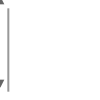

<IPython.core.display.Latex object>

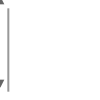

<IPython.core.display.Latex object>

In [ ]:
peaks = [{x: -2, y: 2}, {x: 4, y: 2}]
for peak in peaks:
    line = Line(*Ellipse1.foci).perpendicular_line(Point(peak[x], peak[y]))
    display(line)
    display(Latex(f'{latex(peak)}'))
    plt.append(plot_implicit(line.equation(),
              aspect_ratio=(1, 1), show=False)[0])

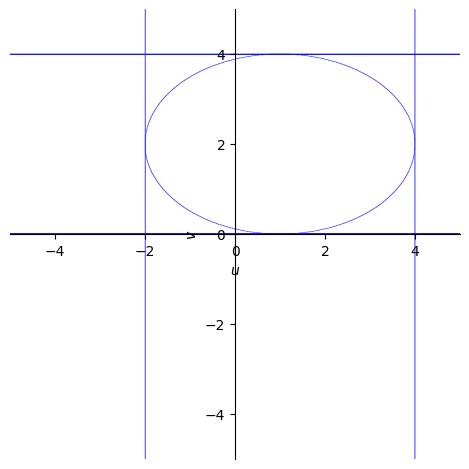

In [ ]:
horizontal_lines = [(Point(-2, 4), Point(4, 4)), (Point(-2, 0), Point(2, 0))]
for line_points in horizontal_lines:
    x, y = symbols('x y')
    equation = Eq(y, line_points[0].y)
    plt.append(plot_implicit(equation, (x, -10, 10), (y, -10, 10),
                             aspect_ratio=(1, 1), show=False)[0])
plt.show()

### Задание 5**.
Построить дочерний класс эллипсов Ellipse_rot, в этом классе должна быть переменная угол поворота, по умолчанию 0 и матрица поворота rot_matr__, по умолчанию None. По умолчанию центр эллипса в начале координат, но при построении экземпляра пользователь может задать другой центр. При построении экземпляра класса пользователь должен иметь возможность задать угол поворота. Матрица поворота - внутренняя переменная, она должна изменяться только при вызове метода change_angle, изменяющего угол поворота.

**Атрибуты класса:**

**focus_distance** фокусное расстояние $c = \sqrt{a^2 - b^2}$

**foci фокусы** в виде кортежа из точек Point

**angle** угол наклона в радианах

**slope** тангенс угла наклона (None для угла, кратного $\pi / 2$, угол от $- 2 \pi$ до $2 \pi$)

**rot_matr** (не путать с rot_matr__!!!) - матрица поворота $\left(\begin{matrix}\cos\alpha&-\sin\alpha\\ \sin\alpha&\cos\alpha\end{matrix}\right).$


**Методы:**

**change_angle** аргумент - новое значение угла поворота, метод изменяет переменную angle и матрицу поворота

**equation** возвращает уравнение эллипса, соответствующее углу поворота эллипса, у этого метода необязательные аргументы - имена переменных, по умолчанию $x$ и $y$.


Протестировать полученный класс так: создать эллипс с осями 12 и 9, центр в точке $(-1, 2)$, угол поворота $\pi / 3$, вывести на экран его эксцентриситет, фокусное расстояние, фокусы, тангенс угла наклона, матрицу поворота и уравнение. Затем заменить угол поворота на $\pi / 4$ и вывести на экран те же атрибуты и результаты работы методов, только уравнение вывести с переменными $u$ и $v$.

In [ ]:
import sympy as sp
from sympy import pi as Pi
from sympy import tan as Tan

In [ ]:
class Ellipse_rot(Ellipse):
  def __init__(self, a, b, angle=0, center=(0, 0)):
    super().__init__(a, b, center)
    self.angle = angle
    self.rot_matr = self.calculate_rotation_matrix(angle)

  def calculate_rotation_matrix(self, angle):
    cos_angle = Cos(angle)
    sin_angle = Sin(angle)
    return [[cos_angle, sin_angle], [-sin_angle, cos_angle]]

  def change_angle(self, new_angle):
    self.angle = new_angle
    self.rot_matr = self.calculate_rotation_matrix(new_angle)

  @property
  def slope(self):
    if self.angle % (Pi/2) == 0:
      return None
    return Tan(self.angle)

  def equation(self, x_var='x', y_var='y'):
    h, k = self.center
    a, b = self.a, self.b
    cos_angle = Cos(self.angle)
    sin_angle = Sin(self.angle)

    return f'(({latex(cos_angle)}({latex(x_var)} - {latex(h)}) + {latex(sin_angle)}({latex(y_var)} - {latex(k)}))^2/{latex(a ** 2)}) + '\
           f'(({latex(sin_angle)}({latex(x_var)} - {latex(h)}) - {latex(cos_angle)}({latex(y_var)} - {latex(k)}))^2/{latex(b ** 2)}) = 1'

In [ ]:
ellipse = Ellipse_rot(a=12, b=9, angle=Pi/3, center=(-1, 2))

display(ellipse.eccentricity)
display(ellipse.focus_distance)
display(Latex(f'{latex(ellipse.foci)}'))
display(ellipse.slope)
display(Latex(f'{latex(ellipse.rot_matr)}'))
display(Latex(ellipse.equation()))

0.661437827766148

3*sqrt(7)

<IPython.core.display.Latex object>

sqrt(3)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [ ]:
ellipse.change_angle(Pi/4)

display(ellipse.eccentricity)
display(ellipse.focus_distance)
display(Latex(f'{latex(ellipse.foci)}'))
display(ellipse.slope)
display(Latex(f'{latex(ellipse.rot_matr)}'))
display(Latex(ellipse.equation()))

0.661437827766148

3*sqrt(7)

<IPython.core.display.Latex object>

1

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

###  Индивидуальное задание. Вариант №191
Эллипс с центром $A$, вертикальной полуосью $b$ и эксцентриситетом $\varepsilon$.
Изобразить на графике эллипс, а также эллипс, повернутый на угол $\alpha$ градусов против часовой стрелки.

Вывести на экран центр и фокусы эллипса, длины полуосей, уравнение эллипса, вершины эллипса.

In [ ]:
center = Point(2, 5)
vertical_radius = 3
eccentricity = sympy.S(2)/5
rotation_angle = Pi/4

ellipse = Ellipse(center, eccentricity=eccentricity, vradius=vertical_radius)

display(Latex(f'Центр\ эллипса:\ {latex(ellipse.center)}'))

<IPython.core.display.Latex object>

In [ ]:
display(Latex(f'Фокус\ эллипса:\ {latex(ellipse.foci)}'))

<IPython.core.display.Latex object>

In [ ]:
display(Latex(f'Длина\ вертикальной\ полуоси:\ {latex(ellipse.vradius)}'))
display(Latex(f'Длина\ горизонтальной\ полуоси:\ {latex(ellipse.hradius)}'))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [ ]:
display(Latex(f'Уравнение\ эллипса:\ {latex(ellipse.equation())}'))

<IPython.core.display.Latex object>

In [ ]:
expr1 = ellipse.equation(x='x', y='y')
expr2 = ellipse.equation(x='x', y='y', _slope=Tan(rotation_angle))

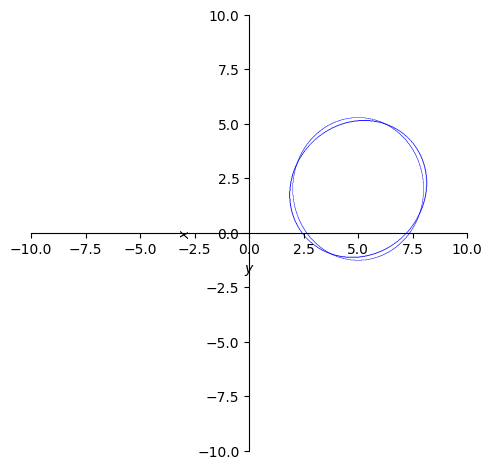

In [ ]:
plt1 = plot_implicit(expr1,
                    aspect_ratio=(1, 1),
                    *[(variable, -10, 10) for variable in expr1.free_symbols], show=False)

plt2 = (plot_implicit(expr2,
                         aspect_ratio=(1, 1),
                         *[(variable, -10, 10) for variable in expr2.free_symbols], show=False))
plt1.extend(plt2)
plt1.show()